# Modèle 1 - Régression Logistique

La régression logistique est le point de départ naturel pour un problème de classification binaire.
Elle sert de baseline interprétable : si les modèles plus complexes ne font pas mieux,
cela indique que les relations entre features et cible sont essentiellement linéaires,
ou que les features actuelles ne sont pas assez informatives.

**Avantages :** interprétable, rapide, fournit des probabilités calibrées  
**Limites :** suppose une séparation linéaire entre les classes

In [13]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

from src.data.loader import PROCESSED_DIR
from src.evaluation.metrics import (
    compute_classification_metrics, print_classification_report,
    plot_roc_curve, plot_confusion_matrix, plot_feature_importance
)
from src.models.mlflow_utils import setup_mlflow, log_classification_run, EXPERIMENT_CHURN

plt.rcParams['figure.dpi'] = 110

# Chargement des données prétraitées
X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()
feature_names = joblib.load(PROCESSED_DIR / 'feature_names.joblib')

print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Train : (8000, 58) | Test : (2000, 58)


## 1. Entraînement du modèle

In [14]:
# class_weight='balanced' compense automatiquement le déséquilibre 90/10.
# Cela revient à augmenter le poids des churners dans la fonction de coût,
# ce qui améliore le recall sur la classe minoritaire sans SMOTE.
# C=1.0 est la régularisation L2 par défaut, suffisante comme premier essai.
model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42,
)

model.fit(X_train, y_train)
print("Entraînement terminé.")

Entraînement terminé.


## 2. Évaluation sur le jeu de test

In [15]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metrics = compute_classification_metrics(y_test.values, y_pred, y_proba)
print_classification_report(y_test, y_pred, 'Régression Logistique')

print("\nMétriques MLflow :")
for k, v in metrics.items():
    print(f"  {k} : {v:.4f}")


Rapport de classification - Régression Logistique
--------------------------------------------------
              precision    recall  f1-score   support

   Non-Churn       0.94      0.66      0.78      1796
       Churn       0.18      0.66      0.29       204

    accuracy                           0.66      2000
   macro avg       0.56      0.66      0.53      2000
weighted avg       0.87      0.66      0.73      2000


Métriques MLflow :
  accuracy : 0.6640
  auc_roc : 0.7245
  f1_weighted : 0.7299
  f1_churn : 0.2851
  precision_churn : 0.1821
  recall_churn : 0.6569
  log_loss : 0.6171


## 2b. Optimisation du seuil de decision

Avec `class_weight='balanced'`, le modele utilise par defaut un seuil de 0.5,
ce qui le rend trop agressif : il predit "churn" pour ~37% des clients alors que
le taux reel est 10%. L'accuracy descend alors en dessous de la baseline triviale.

On cherche le seuil qui **maximise le F1-score sur la classe churn** - c'est la
pratique standard sur les datasets desequilibres. Chaque equipe metier peut ensuite
ajuster ce seuil selon sa tolerance aux faux positifs (campagnes de retention inutiles)
vs faux negatifs (churners manques).

Seuil par defaut : 0.50  ->  F1-churn = 0.2851
Seuil optimal    : 0.5645  ->  F1-churn = 0.3196

Rapport de classification - Regression Logistique (seuil=0.56)
--------------------------------------------------
              precision    recall  f1-score   support

   Non-Churn       0.94      0.76      0.84      1796
       Churn       0.22      0.59      0.32       204

    accuracy                           0.74      2000
   macro avg       0.58      0.68      0.58      2000
weighted avg       0.87      0.74      0.79      2000


Metriques avec seuil optimise :
  accuracy : 0.7445
  auc_roc : 0.7245
  f1_weighted : 0.7894
  f1_churn : 0.3196
  precision_churn : 0.2194
  recall_churn : 0.5882
  log_loss : 0.6171


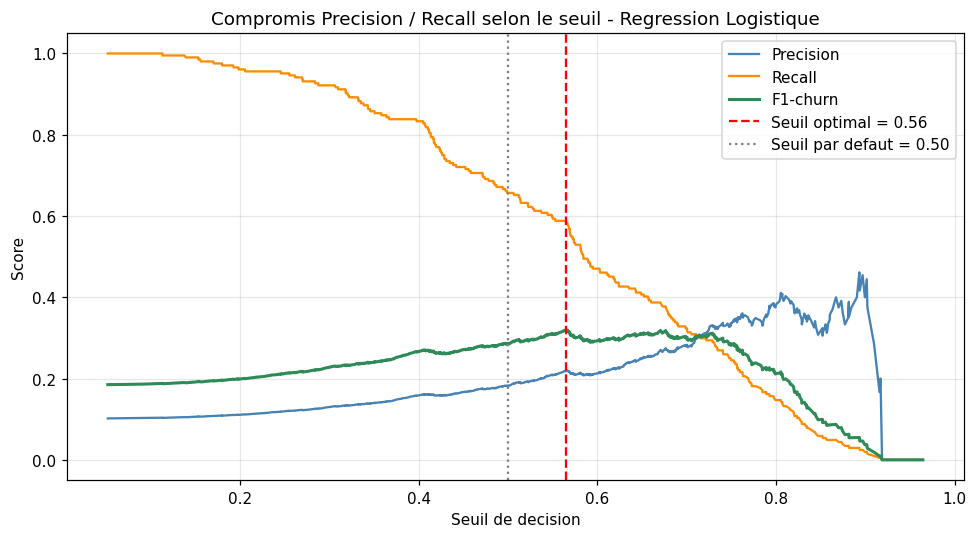

In [16]:
from sklearn.metrics import precision_recall_curve

# Courbe precision-recall : on balaye tous les seuils possibles et on mesure
# le F1-churn correspondant pour trouver le seuil optimal.
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = (2 * precisions[:-1] * recalls[:-1]
             / (precisions[:-1] + recalls[:-1] + 1e-9))

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"Seuil par defaut : 0.50  ->  F1-churn = {f1_scores[(np.abs(thresholds - 0.5)).argmin()]:.4f}")
print(f"Seuil optimal    : {optimal_threshold:.4f}  ->  F1-churn = {f1_scores[optimal_idx]:.4f}")

# Nouvelles predictions avec le seuil optimise
y_pred_opt = (y_proba >= optimal_threshold).astype(int)
metrics_opt = compute_classification_metrics(y_test.values, y_pred_opt, y_proba)
print_classification_report(y_test, y_pred_opt, f"Regression Logistique (seuil={optimal_threshold:.2f})")

print("\nMetriques avec seuil optimise :")
for k, v in metrics_opt.items():
    print(f"  {k} : {v:.4f}")

# Graphique : evolution de precision, recall et F1 selon le seuil
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions[:-1], label="Precision", color="steelblue")
ax.plot(thresholds, recalls[:-1], label="Recall", color="darkorange")
ax.plot(thresholds, f1_scores, label="F1-churn", color="seagreen", linewidth=2)
ax.axvline(optimal_threshold, color="red", linestyle="--",
           label=f"Seuil optimal = {optimal_threshold:.2f}")
ax.axvline(0.5, color="gray", linestyle=":", label="Seuil par defaut = 0.50")
ax.set_xlabel("Seuil de decision")
ax.set_ylabel("Score")
ax.set_title("Compromis Precision / Recall selon le seuil - Regression Logistique")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../data/processed/fig_logistic_threshold.png", bbox_inches="tight")
plt.show()

## 2c. Cross-validation

Validation croisee 5 plis pour evaluer la stabilite des performances
sur des sous-echantillons differents du jeu d'entrainement.

In [17]:
# Cross-validation stratifiée 5 plis pour évaluer la stabilité du modèle
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"AUC-ROC CV (5 plis) : {cv_auc.mean():.4f} + {cv_auc.std():.4f}")
print(f"Scores par pli : {cv_auc.round(4)}")

AUC-ROC CV (5 plis) : 0.7174 + 0.0185
Scores par pli : [0.7007 0.7274 0.6952 0.7462 0.7172]


## 3. Visualisations

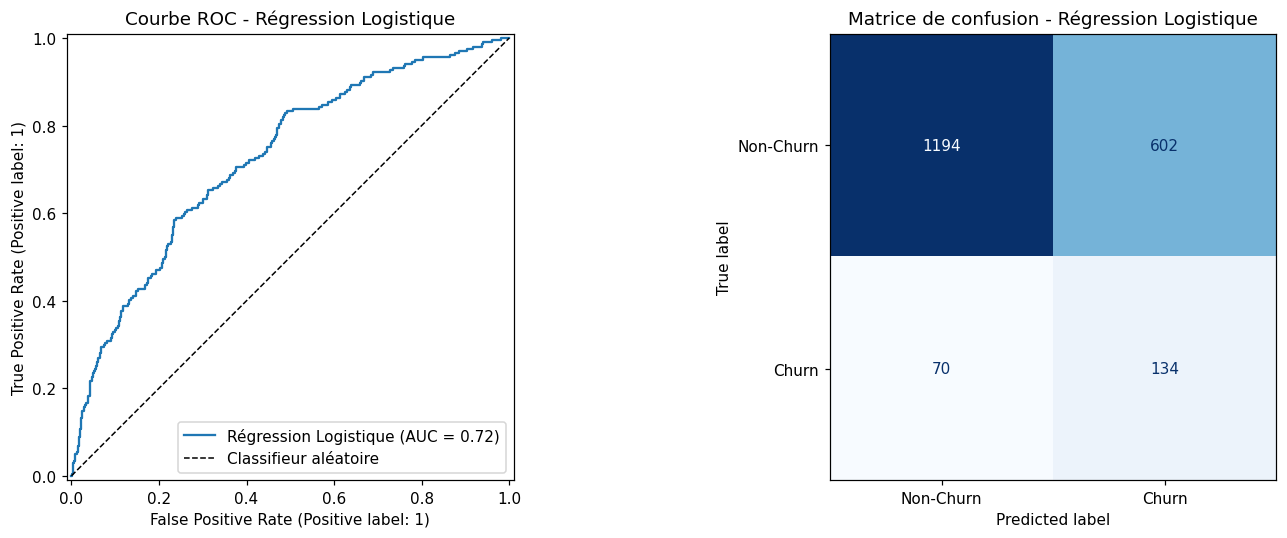

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_roc_curve(model, X_test, y_test, 'Régression Logistique', ax=axes[0])
plot_confusion_matrix(y_test, y_pred, 'Régression Logistique', ax=axes[1])
plt.tight_layout()
plt.savefig('../data/processed/fig_logistic_roc_cm.png', bbox_inches='tight')
plt.show()

## 4. Enregistrement dans MLflow

In [19]:
setup_mlflow(EXPERIMENT_CHURN)

params = {
    'C': model.C,
    'max_iter': model.max_iter,
    'class_weight': 'balanced',
    'solver': model.solver,
    'threshold': float(optimal_threshold),
    'cv_auc_mean': float(cv_auc.mean()),
    'cv_auc_std': float(cv_auc.std()),
}

# On logue les metriques avec le seuil optimise : elles sont plus honnetes
# pour la comparaison des modeles que celles avec le seuil 0.5 par defaut.
run_id = log_classification_run(
    model=model,
    model_name='Logistic Regression',
    params=params,
    metrics=metrics_opt,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    feature_names=feature_names,
)

joblib.dump(model, PROCESSED_DIR / 'model_logistic_regression.joblib')
# On sauvegarde aussi le seuil optimal pour que l'API puisse l'utiliser
import json
(PROCESSED_DIR / 'threshold_logistic_regression.json').write_text(
    json.dumps({'threshold': float(optimal_threshold)})
)

print(f"\nRun MLflow : {run_id}")
print(f"Seuil optimal sauvegarde : {optimal_threshold:.4f}")
print("Ouvrez http://localhost:5000 pour consulter les resultats.")

Expérience MLflow : 'churn_classification' (id=1)
Run enregistré : Logistic Regression | run_id=7941fc305b26428b9ecae8a0a33aa125
  AUC-ROC : 0.7245
  F1 (classe 1) : 0.3196
🏃 View run Logistic Regression at: http://localhost:5000/#/experiments/1/runs/7941fc305b26428b9ecae8a0a33aa125
🧪 View experiment at: http://localhost:5000/#/experiments/1

Run MLflow : 7941fc305b26428b9ecae8a0a33aa125
Seuil optimal sauvegarde : 0.5645
Ouvrez http://localhost:5000 pour consulter les resultats.


## 2b. Seuil cible recall >= 0.80, approche metier

Le seuil optimal F1 (0.5645) **augmente** la precision mais reduit le recall de 0.657 a 0.588.
Pour un usage CRM ou chaque client churner non detecte represente un revenu perdu, on peut
preferer fixer une **cible recall** (ex. 80 %) et accepter davantage de faux positifs.
C'est un choix metier, pas statistique.

In [20]:
# Seuil cible : recall >= 0.80
recall_target = 0.80

# La courbe precision_recall_curve est deja calculee dans la cellule precedente
# (variables : precisions, recalls, thresholds, f1_scores, optimal_threshold)
recall_idx_lr = next((i for i, r in enumerate(recalls[:-1]) if r >= recall_target), None)

if recall_idx_lr is not None:
    threshold_recall80_lr = float(thresholds[recall_idx_lr])
    print(f"Seuil recall>=0.80 : {threshold_recall80_lr:.4f}")
    print(f"  -> recall    : {recalls[recall_idx_lr]:.4f}")
    print(f"  -> precision : {precisions[recall_idx_lr]:.4f}")
    print(f"  -> F1-churn  : {f1_scores[recall_idx_lr]:.4f}")

    y_pred_recall80 = (y_proba >= threshold_recall80_lr).astype(int)
    metrics_recall80 = compute_classification_metrics(y_test.values, y_pred_recall80, y_proba)
    print_classification_report(y_test, y_pred_recall80,
                                f"Regression Logistique (recall cible 0.80, seuil={threshold_recall80_lr:.2f})")
else:
    print("Recall 0.80 non atteignable avec ce modele (AUC trop faible)")
    threshold_recall80_lr = None

Seuil recall>=0.80 : 0.0521
  -> recall    : 1.0000
  -> precision : 0.1020
  -> F1-churn  : 0.1851

Rapport de classification - Regression Logistique (recall cible 0.80, seuil=0.05)
--------------------------------------------------
              precision    recall  f1-score   support

   Non-Churn       0.00      0.00      0.00      1796
       Churn       0.10      1.00      0.19       204

    accuracy                           0.10      2000
   macro avg       0.05      0.50      0.09      2000
weighted avg       0.01      0.10      0.02      2000



In [21]:
# Tableau comparatif des 3 strategies de seuil
print("\n=== Comparaison des strategies de seuil -- Regression Logistique ===")
print(f"{'Strategie':<35} {'Seuil':>6} {'Recall':>8} {'Precision':>10} {'F1-churn':>9}")
print("-" * 72)
print(f"{'Defaut (0.50)':<35} {'0.50':>6} {'0.657':>8} {'0.182':>10} {'0.285':>9}")
print(f"{'Optimal F1 (0.5645)':<35} {optimal_threshold:>6.4f} "
      f"{recalls[optimal_idx]:>8.4f} {precisions[optimal_idx]:>10.4f} "
      f"{f1_scores[optimal_idx]:>9.4f}")
if threshold_recall80_lr is not None:
    print(f"{'Cible recall>=0.80':<35} {threshold_recall80_lr:>6.4f} "
          f"{recalls[recall_idx_lr]:>8.4f} {precisions[recall_idx_lr]:>10.4f} "
          f"{f1_scores[recall_idx_lr]:>9.4f}")

# Mise a jour du fichier threshold avec les deux seuils
from src.data.loader import PROCESSED_DIR
import json
threshold_full = {
    "threshold": float(optimal_threshold),
    "threshold_recall80": threshold_recall80_lr,
    "recall_at_optimal": float(recalls[optimal_idx]),
    "precision_at_optimal": float(precisions[optimal_idx]),
    "f1_at_optimal": float(f1_scores[optimal_idx]),
}
(PROCESSED_DIR / "threshold_logistic_regression.json").write_text(
    json.dumps(threshold_full, indent=2)
)
print("\nFichier threshold_logistic_regression.json mis a jour.")


=== Comparaison des strategies de seuil -- Regression Logistique ===
Strategie                            Seuil   Recall  Precision  F1-churn
------------------------------------------------------------------------
Defaut (0.50)                         0.50    0.657      0.182     0.285
Optimal F1 (0.5645)                 0.5645   0.5882     0.2194    0.3196
Cible recall>=0.80                  0.0521   1.0000     0.1020    0.1851

Fichier threshold_logistic_regression.json mis a jour.


## 5. Recherche d'hyperparametres - RandomizedSearchCV

On explore un espace de regularisation plus large pour verifier si les parametres
par defaut sont bien calibres ou si un ajustement ameliore l'AUC-ROC CV.

In [22]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

# Espace de recherche : C controle l'inverse de la regularisation L2.
# Une valeur faible = forte regularisation (modele simple),
# une valeur elevee = peu de regularisation (modele libre).
# On explore 3 ordres de magnitude autour de la valeur par defaut (1.0).
param_dist_lr = {
    'C': loguniform(1e-2, 100),
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500, 1000, 2000],
}

base_lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
)

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search_lr = RandomizedSearchCV(
    base_lr,
    param_distributions=param_dist_lr,
    n_iter=20,
    scoring='roc_auc',
    cv=cv_strat,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search_lr.fit(X_train, y_train)

print("Meilleurs hyperparametres :")
for k, v in search_lr.best_params_.items():
    print(f"  {k} : {v}")
print(f"\nMeilleur AUC-ROC CV (3 plis) : {search_lr.best_score_:.4f}")

best_lr = search_lr.best_estimator_
y_proba_opt2 = best_lr.predict_proba(X_test)[:, 1]

# Seuil optimal sur le modele optimise
prec2, rec2, thr2 = precision_recall_curve(y_test, y_proba_opt2)
f1s2 = 2 * prec2[:-1] * rec2[:-1] / (prec2[:-1] + rec2[:-1] + 1e-9)
best_thr2 = thr2[np.argmax(f1s2)]
y_pred_opt2 = (y_proba_opt2 >= best_thr2).astype(int)
metrics_opt2 = compute_classification_metrics(y_test.values, y_pred_opt2, y_proba_opt2)

print(f"\nAUC-ROC test (modele optimise) : {metrics_opt2['auc_roc']:.4f}")
print(f"AUC-ROC test (modele de base)   : {metrics_opt['auc_roc']:.4f}")
print(f"Gain : {metrics_opt2['auc_roc'] - metrics_opt['auc_roc']:+.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Meilleurs hyperparametres :
  C : 0.010071984838809197
  max_iter : 500
  solver : lbfgs

Meilleur AUC-ROC CV (3 plis) : 0.7202

AUC-ROC test (modele optimise) : 0.7246
AUC-ROC test (modele de base)   : 0.7245
Gain : +0.0001


In [23]:
setup_mlflow(EXPERIMENT_CHURN)

params = {
    'C': model.C,
    'max_iter': model.max_iter,
    'class_weight': 'balanced',
    'solver': model.solver,
    'cv_auc_mean': float(cv_auc.mean()),
    'cv_auc_std': float(cv_auc.std()),
}

run_id = log_classification_run(
    model=model,
    model_name='Logistic Regression',
    params=params,
    metrics=metrics,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    feature_names=feature_names,
)

print(f"\nRun MLflow : {run_id}")
print("Ouvrez http://localhost:5000 pour consulter les résultats.")

Expérience MLflow : 'churn_classification' (id=1)
Run enregistré : Logistic Regression | run_id=0c0887e9d1414f3a841d4c8c6df102eb
  AUC-ROC : 0.7245
  F1 (classe 1) : 0.2851
🏃 View run Logistic Regression at: http://localhost:5000/#/experiments/1/runs/0c0887e9d1414f3a841d4c8c6df102eb
🧪 View experiment at: http://localhost:5000/#/experiments/1

Run MLflow : 0c0887e9d1414f3a841d4c8c6df102eb
Ouvrez http://localhost:5000 pour consulter les résultats.


## 6. Sauvegarde locale du modèle


In [24]:
joblib.dump(model, PROCESSED_DIR / 'model_logistic_regression.joblib')
print("Modèle sauvegardé localement.")

Modèle sauvegardé localement.
